# Urban Risk, Arequipa Perú Data Analysis

I encourage to read the medium post I've created before reading the notebook

https://medium.com/@jamesev1502/urban-risk-index-in-arequipa-per%C3%BA-779e3e12144e

Full Github Project

https://github.com/jamesev15/urban-risk-data-analysis/tree/main


# **Be sure the below is present before running the notebook**
- air-data.zip (zip file, it could be uploaded as zip file, the below code will unpack the zip)
- arequipa-districts-points.json (file)
- arequipa.txt (file)
- denuncias.csv

# Unzip the air-data.zip
The air-data.zip can be upload as zip, the below code will unpack the zip

In [243]:
from zipfile import ZipFile

In [244]:
with ZipFile("air-data.zip") as zObject:
    zObject.extractall(path=".")

# Loading Arequipa's districts

There is a filed named 'arequipa.txt' that contains all districts from Metropolitan Arequipa


In [245]:
%pip install osmnx~=2.0.6 shapely~=2.1.1 geopandas~=1.1.1 matplotlib contextily~=1.6.2 python-dotenv~=1.1.1 httpx~=0.28.1


In [246]:
with open("arequipa.txt", "r") as f:
    districts = f.readlines()

districts = [district.strip() for district in districts]

In [247]:
districts

['Arequipa, Arequipa, Peru',
 'Alto Selva Alegre, Arequipa, Peru',
 'Cayma, Arequipa, Peru',
 'Cerro Colorado, Arequipa, Peru',
 'Characato, Arequipa, Peru',
 'Chiguata, Arequipa, Peru',
 'Jacobo Hunter, Arequipa, Peru',
 'José Luis Bustamante y Rivero, Arequipa, Peru',
 'La Joya, Arequipa, Peru',
 'Mariano Melgar, Arequipa, Peru',
 'Miraflores, Arequipa, Peru',
 'Mollebaya, Arequipa, Peru',
 'Paucarpata, Arequipa, Peru',
 'Pocsi, Arequipa, Peru',
 'Polobaya, Arequipa, Peru',
 'Quequeña, Arequipa, Peru',
 'Sabandía, Arequipa, Peru',
 'Sachaca, Arequipa, Peru',
 'San Juan de Siguas, Arequipa, Peru',
 'San Juan de Tarucani, Arequipa, Peru',
 'Santa Isabel de Siguas, Arequipa, Peru',
 'Santa Rita de Siguas, Arequipa, Peru',
 'Socabaya, Arequipa, Peru',
 'Tiabaya, Arequipa, Peru',
 'Uchumayo, Arequipa, Peru',
 'Vítor, Arequipa, Peru',
 'Yanahuara, Arequipa, Peru',
 'Yarabamba, Arequipa, Peru',
 'Yura, Arequipa, Peru']

# Getting center for each district

In [248]:
import osmnx as ox

def get_district_center(district_name: str) -> tuple[float, float]:
    gdf = ox.geocode_to_gdf(district_name)
    gdf_utm = gdf.to_crs(32719)
    centroid = gdf_utm.to_crs(4326).geometry.centroid.iloc[0]
    return centroid.y, centroid.x


Creates a district points dict that contains district as keys and tuple of latitude, longitude as first element of a list

In [249]:
district_points = {}

for district in districts:
    if district not in district_points:
        district_points[district] = []

    district_points[district].append(get_district_center(district))

/tmp/ipython-input-1812255738.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = gdf_utm.to_crs(4326).geometry.centroid.iloc[0]
/tmp/ipython-input-1812255738.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = gdf_utm.to_crs(4326).geometry.centroid.iloc[0]
/tmp/ipython-input-1812255738.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = gdf_utm.to_crs(4326).geometry.centroid.iloc[0]
/tmp/ipython-input-1812255738.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to r

In [250]:
district_points

{'Arequipa, Arequipa, Peru': [(-16.406798376200378, -71.5381863402169)],
 'Alto Selva Alegre, Arequipa, Peru': [(-16.331058419570862,
   -71.48553023369436)],
 'Cayma, Arequipa, Peru': [(-16.252908478161892, -71.45712989147931)],
 'Cerro Colorado, Arequipa, Peru': [(-16.30442116329215, -71.57658710199709)],
 'Characato, Arequipa, Peru': [(-16.45774274090861, -71.38286833438315)],
 'Chiguata, Arequipa, Peru': [(-16.375575727363618, -71.35864450057483)],
 'Jacobo Hunter, Arequipa, Peru': [(-16.458777719380826, -71.562712786759)],
 'José Luis Bustamante y Rivero, Arequipa, Peru': [(-16.43173015002676,
   -71.52301342455694)],
 'La Joya, Arequipa, Peru': [(-16.588391654083093, -71.7957247087483)],
 'Mariano Melgar, Arequipa, Peru': [(-16.375465532154976, -71.46294401224344)],
 'Miraflores, Arequipa, Peru': [(-16.356374523135607, -71.47112282801574)],
 'Mollebaya, Arequipa, Peru': [(-16.504079395989216, -71.47384476890862)],
 'Paucarpata, Arequipa, Peru': [(-16.420118919012957, -71.47792756

# Get other points from center and check if belongs to right district

In [251]:
import math
from shapely.geometry import Point

def get_point_from_reference(latitude, longitude, distance_m, bearing_deg):
    R = 6371000.0 # Earth radius
    phi1 = math.radians(latitude)
    lam1 = math.radians(longitude)
    theta = math.radians(bearing_deg)
    d_R = distance_m / R

    sin_phi2 = math.sin(phi1)*math.cos(d_R) + math.cos(phi1)*math.sin(d_R)*math.cos(theta)
    phi2 = math.asin(sin_phi2)

    y = math.sin(theta) * math.sin(d_R) * math.cos(phi1)
    x = math.cos(d_R) - math.sin(phi1) * math.sin(phi2)
    lam2 = lam1 + math.atan2(y, x)

    lon2 = (math.degrees(lam2) + 540) % 360 - 180
    lat2 = math.degrees(phi2)
    return lat2, lon2

def point_belongs_to_district(latitude, longitude, district_name) -> bool:
    pt = Point(longitude, latitude)

    gdf = ox.geocode_to_gdf(district_name)

    gdf = gdf.to_crs("EPSG:4326")
    poly = gdf.geometry.iloc[0]

    return poly.covers(pt)

In [252]:
DEGREES = (0, 90, 180, 270)
DISTANCE = 1500 # since the resolution of the Air Quality is 500x500, 1500 meters was choosen for avoid same measures

district_full_points = {**district_points}

for district_name, center in district_points.items():
    center_latitude, center_longitude = center[0]
    for cardinal_degrees in DEGREES:
        point = get_point_from_reference(
            latitude=center_latitude,
            longitude=center_longitude,
            distance_m=DISTANCE,
            bearing_deg=cardinal_degrees,
        )
        latitude, longitude = point
        if point_belongs_to_district(latitude, longitude, district_name):
            district_full_points[district_name].append((latitude, longitude))
        else:
            print(f"{latitude},{longitude} does not belong to {district_name}")

-16.420288200289157,-71.5381863402169 does not belong to Arequipa, Arequipa, Peru
-16.40679790861164,-71.5522487802786 does not belong to Arequipa, Arequipa, Peru
-16.45877725022609,-71.5486465834947 does not belong to Jacobo Hunter, Arequipa, Peru
-16.431729681686996,-71.50894918117945 does not belong to José Luis Bustamante y Rivero, Arequipa, Peru
-16.445219974115542,-71.52301342455695 does not belong to José Luis Bustamante y Rivero, Arequipa, Peru
-16.431729681686996,-71.5370776679344 does not belong to José Luis Bustamante y Rivero, Arequipa, Peru
-16.375465065509815,-71.47700419043025 does not belong to Mariano Melgar, Arequipa, Peru
-16.342884699046827,-71.47112282801572 does not belong to Miraflores, Arequipa, Peru
-16.36986434722439,-71.47112282801572 does not belong to Miraflores, Arequipa, Peru
-16.356374057065214,-71.48518163046663 does not belong to Miraflores, Arequipa, Peru
-16.463467636012872,-71.58492639971342 does not belong to Tiabaya, Arequipa, Peru
-16.38129878352

In [253]:
district_full_points

{'Arequipa, Arequipa, Peru': [(-16.406798376200378, -71.5381863402169),
  (-16.3933085521116, -71.5381863402169),
  (-16.40679790861164, -71.52412390015519)],
 'Alto Selva Alegre, Arequipa, Peru': [(-16.331058419570862,
   -71.48553023369436),
  (-16.31756859548208, -71.48553023369436),
  (-16.33105795426248, -71.47147325275023),
  (-16.34454824365964, -71.48553023369436),
  (-16.33105795426248, -71.4995872146385)],
 'Cayma, Arequipa, Peru': [(-16.252908478161892, -71.45712989147931),
  (-16.239418654073113, -71.45712989147933),
  (-16.25290801520457, -71.44307851318814),
  (-16.26639830225067, -71.45712989147933),
  (-16.25290801520457, -71.47118126977045)],
 'Cerro Colorado, Arequipa, Peru': [(-16.30442116329215, -71.57658710199709),
  (-16.29093133920337, -71.57658710199712),
  (-16.304420698785336, -71.56253203414576),
  (-16.31791098738093, -71.57658710199712),
  (-16.304420698785336, -71.59064216984848)],
 'Characato, Arequipa, Peru': [(-16.45774274090861, -71.38286833438315),
  

In [254]:
import json

with open("arequipa-districts-points.json", "w") as f:
    f.write(json.dumps(district_full_points, indent=4))


# Show points for Metropolitan Arequipa

In [255]:
full_points = []

for district_name, district_points in district_full_points.items():
    for point in district_points:
        full_points.append({
            "id": district_name[:2],
            "lat": point[0],
            "lon": point[1],
        })

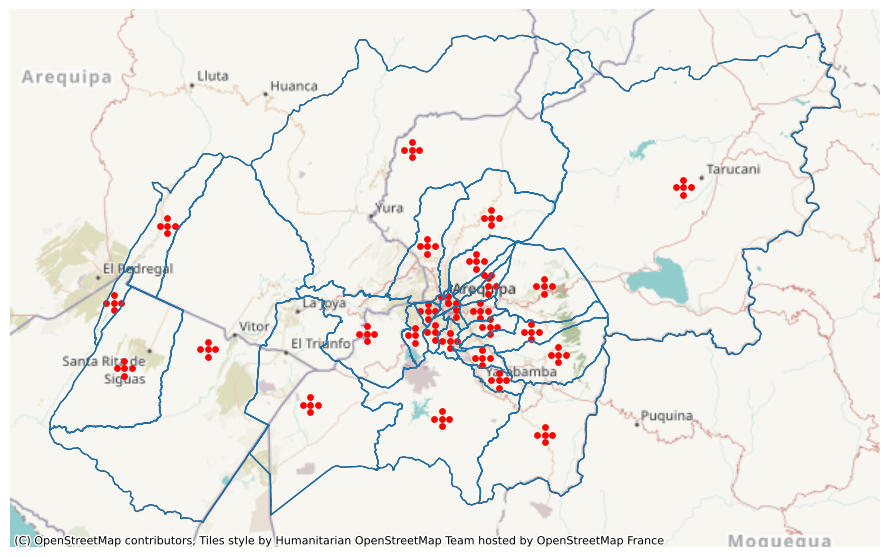

In [256]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as cx

gdfs = []
for q in districts:
    gd = ox.geocode_to_gdf(q)[["geometry"]].copy()
    gd["distrito"] = q.split(",")[0]  # nombre corto
    gdfs.append(gd)

gdf_distritos = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs="EPSG:4326")

# Convert points to dataframe
df_pts = pd.DataFrame(full_points)
gdf_pts = gpd.GeoDataFrame(
    df_pts,
    geometry=[Point(lon, lat) for lat, lon in zip(df_pts["lat"], df_pts["lon"])],
    crs="EPSG:4326",
)

# Graph districs
gdf_distritos_3857 = gdf_distritos.to_crs(3857)
gdf_pts_3857 = gdf_pts.to_crs(3857)

ax = gdf_distritos_3857.boundary.plot(linewidth=1.0, alpha=0.9, figsize=(9, 9))
gdf_distritos_3857.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.8)

# Points
gdf_pts_3857.plot(ax=ax, markersize=15, color="red")

# Add map for Arequipa(Provincia)
cx.add_basemap(ax, crs=gdf_distritos_3857.crs)

# Plot
ax.set_axis_off()
plt.tight_layout()
plt.show()


# Load Google Air Quality Token

Obtaining api token: https://developers.google.com/maps/documentation/air-quality/get-api-key?hl=es-419

Create an .env file that contains

```bash
GOOGLE_AIR_QUALITY_TOKEN=replace-me
```

In [257]:
from dotenv import load_dotenv

load_dotenv()

False

# Air Quality Class for data from Google Air Quality API

In [258]:
import httpx
import os
from enum import Enum

class ExtraComputations(str, Enum):
    EXTRA_COMPUTATION_UNSPECIFIED = "EXTRA_COMPUTATION_UNSPECIFIED"
    LOCAL_AQI = "LOCAL_AQI"
    HEALTH_RECOMMENDATIONS = "HEALTH_RECOMMENDATIONS"
    POLLUTANT_ADDITIONAL_INFO = "POLLUTANT_ADDITIONAL_INFO"
    DOMINANT_POLLUTANT_CONCENTRATION = "DOMINANT_POLLUTANT_CONCENTRATION"
    POLLUTANT_CONCENTRATION = "POLLUTANT_CONCENTRATION"


class AirQuality:
    base_url: str
    headers: dict
    query_params: dict
    http_client: httpx.AsyncClient

    def __init__(self, base_url: str = "https://airquality.googleapis.com/v1") -> None:
        self.base_url = base_url
        self.headers = {"Content-Type": "application/json"}
        self.query_params = {"key": os.getenv("GOOGLE_AIR_QUALITY_TOKEN")}
        self.http_client = httpx.AsyncClient()

    async def get_current_conditions(self, latitude: float, longitude: float, extra_computations: list[ExtraComputations]) -> dict | None:
        url = f"{self.base_url}/currentConditions:lookup"

        payload = {
            "location": {
                "latitude": latitude,
                "longitude": longitude
            },
            "extraComputations": extra_computations
        }

        try:
            response = await self.http_client.post(
                url=url,
                headers=self.headers,
                params=self.query_params,
                json=payload
            )
            response.raise_for_status()
            return response.json()
        except Exception as e:
            print(f"Current conditions error for lat={latitude},long={longitude}. Error={e}")
            return None

    async def get_history_conditions(
        self,
        latitude: float,
        longitude: float,
        hours: int,
        extra_computations: list[ExtraComputations]
    ) -> list[dict]:

        url = f"{self.base_url}/history:lookup"

        payload = {
            "hours": hours,
            "pageSize": 72, # default value: 72
            "pageToken": "",
            "location": {
                "latitude": latitude,
                "longitude": longitude
            },
            "extraComputations": extra_computations
        }

        points = []
        next_page_token = True
        # Start request
        while next_page_token:
            response = await self.http_client.post(
                url=url,
                headers=self.headers,
                params=self.query_params,
                json=payload
            )

            data: dict = response.json()
            points.extend(data["hoursInfo"])
            next_page_token = data.get("nextPageToken")
            payload.update({"pageToken": next_page_token})

        return points


# Load districts with points based on Metropolitan Arequipa

In [259]:
import json

with open("arequipa-districts-points.json", "r") as f:
    districts: dict = json.loads(f.read())


# Get history data and dumps per district and point into a JSONL. It will retrieve data from Google API just if token is present, else it will take the data from "air-data" dir

In [260]:
air_quality = AirQuality()

In [261]:
import asyncio
import pathlib

air_quality_dir = pathlib.Path("air-data")

for district_name, points in districts.items():
    print(f"Getting air quality data in {district_name} for {len(points)} points ...")
    tasks = []
    for point in points:
        tasks.append(air_quality.get_history_conditions(
            latitude=point[0],
            longitude=point[1],
            hours=720,
            extra_computations=[ExtraComputations.POLLUTANT_CONCENTRATION, ExtraComputations.HEALTH_RECOMMENDATIONS],
        ))

    results = await asyncio.gather(*tasks, return_exceptions=True)
    for (i, result), point in zip(enumerate(results), points):
        if isinstance(result, Exception):
            print(f"{district_name} couldn't get air quality data. Skip it, error {result}")
            continue

        district_name_normalized = district_name.strip().replace(" ", "").replace(",", "_").lower()
        fname = air_quality_dir / pathlib.Path(f"{district_name_normalized}_{i}.jsonl")

        with open(fname, "w") as f:
            for record in result:
                record["latitude"] = point[0]
                record["longitude"] = point[1]
                record["point"] = f"{district_name_normalized}_{i}"
                f.write(json.dumps(record) + "\n")


Getting air quality data in Arequipa, Arequipa, Peru for 3 points ...
Arequipa, Arequipa, Peru couldn't get air quality data. Skip it, error 'hoursInfo'
Arequipa, Arequipa, Peru couldn't get air quality data. Skip it, error 'hoursInfo'
Arequipa, Arequipa, Peru couldn't get air quality data. Skip it, error 'hoursInfo'
Getting air quality data in Alto Selva Alegre, Arequipa, Peru for 5 points ...
Alto Selva Alegre, Arequipa, Peru couldn't get air quality data. Skip it, error 'hoursInfo'
Alto Selva Alegre, Arequipa, Peru couldn't get air quality data. Skip it, error 'hoursInfo'
Alto Selva Alegre, Arequipa, Peru couldn't get air quality data. Skip it, error 'hoursInfo'
Alto Selva Alegre, Arequipa, Peru couldn't get air quality data. Skip it, error 'hoursInfo'
Alto Selva Alegre, Arequipa, Peru couldn't get air quality data. Skip it, error 'hoursInfo'
Getting air quality data in Cayma, Arequipa, Peru for 5 points ...
Cayma, Arequipa, Peru couldn't get air quality data. Skip it, error 'hoursI

# Load Air Quality points


In [262]:
import pathlib


air_quality_dir = pathlib.Path("air-data")

points = []
for file in air_quality_dir.iterdir():
    with open(file, "r") as f:
        points.extend(f.readlines())

In [263]:
import json

air_quality_points = [json.loads(point.strip()) for point in points]

In [264]:
len(air_quality_points)

93600

In [265]:
data = []

for aq_point in air_quality_points:
    for pollutant in aq_point.get("pollutants", []):
        aq_data = {"datetime": aq_point.get("dateTime")}

        pollutant_code = pollutant.get("code")
        aq_data["pollutant_code"] = pollutant_code
        aq_data["value"] = pollutant.get("concentration", {}).get("value")
        aq_data["units"] = pollutant.get("concentration", {}).get("units")

        aq_data["latitude"] = aq_point.get("latitude")
        aq_data["longitude"] = aq_point.get("longitude")
        aq_data["point_name"] = aq_point.get("point")

        data.append(aq_data)

In [266]:
import pandas as pd

df = pd.DataFrame(data)

## Sample of air quality data

In [267]:
df.sample(5)

,datetime,pollutant_code,value,units,latitude,longitude,point_name
506416,2025-09-03T19:00:00Z,pm25,10.53,MICROGRAMS_PER_CUBIC_METER,-16.489368,-71.973699,vítor_arequipa_peru_2
544395,2025-09-05T13:00:00Z,pm10,110.45,MICROGRAMS_PER_CUBIC_METER,-16.418240,-71.523013,joséluisbustamanteyrivero_arequipa_peru_1
407628,2025-08-12T07:00:00Z,co,87.70,PARTS_PER_BILLION,-16.184721,-71.098042,sanjuandetarucani_arequipa_peru_1
193217,2025-08-26T07:00:00Z,so2,1.08,PARTS_PER_BILLION,-16.475879,-71.987767,vítor_arequipa_peru_1
429414,2025-09-07T12:00:00Z,co,331.73,PARTS_PER_BILLION,-16.331058,-71.471473,altoselvaalegre_arequipa_peru_2


## Removing numbers for creating district name

In [268]:
df["district_name"] = df["point_name"].str[:-2]

## Average the pollulant value grouping by district, pollulant code and datetime. That will returns a representative value per pollulant

In [269]:
df_average = df.groupby(['district_name', 'pollutant_code', 'datetime']).agg({
    'value': 'mean',
    'units': 'first',
    'latitude': 'first',
    'longitude': 'first',
}).reset_index()

In [270]:
df_average.head()

,district_name,pollutant_code,datetime,value,units,latitude,longitude
0,altoselvaalegre_arequipa_peru,co,2025-08-11T02:00:00Z,376.674,PARTS_PER_BILLION,-16.331058,-71.48553
1,altoselvaalegre_arequipa_peru,co,2025-08-11T03:00:00Z,432.960,PARTS_PER_BILLION,-16.331058,-71.48553
2,altoselvaalegre_arequipa_peru,co,2025-08-11T04:00:00Z,407.316,PARTS_PER_BILLION,-16.331058,-71.48553
3,altoselvaalegre_arequipa_peru,co,2025-08-11T05:00:00Z,381.666,PARTS_PER_BILLION,-16.331058,-71.48553
4,altoselvaalegre_arequipa_peru,co,2025-08-11T06:00:00Z,356.106,PARTS_PER_BILLION,-16.331058,-71.48553


## Cast the datetime object to datetime type

In [271]:
df_average["datetime"] = pd.to_datetime(df_average["datetime"])

## Define the morning, evening and night hours for adding 'day_period'

In [272]:
from datetime import datetime, timedelta

def day_period(dt: datetime):
    dt_peru = dt - timedelta(hours=5)

    if dt_peru.hour > 6 and dt_peru.hour < 10:
        return 'morning'
    elif dt_peru.hour > 12 and dt_peru.hour < 16:
        return 'evening'
    elif dt_peru.hour > 18 and dt_peru.hour < 22:
        return 'night'
    else:
        return 'normal'

df_average['day_period'] = df_average['datetime'].apply(day_period)

In [273]:
df_average.sample(5)

,district_name,pollutant_code,datetime,value,units,latitude,longitude,day_period
85547,santaisabeldesiguas_arequipa_peru,co,2025-09-05 01:00:00+00:00,69.070,PARTS_PER_BILLION,-16.267689,-72.049173,night
88601,santaisabeldesiguas_arequipa_peru,so2,2025-08-15 07:00:00+00:00,0.720,PARTS_PER_BILLION,-16.267689,-72.049173,normal
44359,miraflores_arequipa_peru,o3,2025-08-30 21:00:00+00:00,54.400,PARTS_PER_BILLION,-16.356375,-71.471123,normal
19890,characato_arequipa_peru,pm25,2025-08-13 20:00:00+00:00,14.898,MICROGRAMS_PER_CUBIC_METER,-16.457742,-71.368802,evening
71003,sabandía_arequipa_peru,pm25,2025-08-19 13:00:00+00:00,23.092,MICROGRAMS_PER_CUBIC_METER,-16.461754,-71.460156,morning


## Select max pollulant value grouping by district, pollulant code and day period

In [274]:
df_max = df_average.groupby(['district_name', 'pollutant_code', 'day_period']).agg({
    'value': 'max',
    'latitude': 'first',
    'longitude': 'first',
    'units': 'first',
}).reset_index()

## Normalize district name

In [275]:
df_max["district_name"] = df_max["district_name"].str.replace("á", "a").str.replace("é", "e").str.replace("í", "i").str.replace("ó", "o").str.replace("ú", "u")

In [276]:
df_max.sample(5)

,district_name,pollutant_code,day_period,value,latitude,longitude,units
211,lajoya_arequipa_peru,pm25,normal,23.484,-16.588392,-71.795725,MICROGRAMS_PER_CUBIC_METER
633,yanahuara_arequipa_peru,o3,morning,46.710,-16.394789,-71.550419,PARTS_PER_BILLION
435,sanjuandesiguas_arequipa_peru,co,normal,208.288,-16.405124,-72.177388,PARTS_PER_BILLION
52,cayma_arequipa_peru,no2,evening,0.856,-16.266398,-71.457130,PARTS_PER_BILLION
119,characato_arequipa_peru,so2,normal,2.940,-16.457742,-71.368802,PARTS_PER_BILLION


## Filter by NO2 pollulant for incoming analysis

In [277]:
df_no2 = df_max[df_max['pollutant_code'] == 'no2']

In [278]:
top_no2 = df_no2[(df_no2["day_period"] == "morning") | (df_no2["day_period"] == "evening") | (df_no2["day_period"] == "night")].sort_values(by="value", ascending=False).head(10)
top_no2

,district_name,pollutant_code,day_period,value,latitude,longitude,units
630,yanahuara_arequipa_peru,no2,night,46.130000,-16.394789,-71.550419,PARTS_PER_BILLION
30,arequipa_arequipa_peru,no2,night,43.696667,-16.406798,-71.524124,PARTS_PER_BILLION
174,joseluisbustamanteyrivero_arequipa_peru,no2,night,42.325000,-16.431730,-71.523013,PARTS_PER_BILLION
414,sachaca_arequipa_peru,no2,night,38.588000,-16.421063,-71.576245,PARTS_PER_BILLION
150,jacobohunter_arequipa_peru,no2,night,33.147500,-16.458778,-71.562713,PARTS_PER_BILLION
294,paucarpata_arequipa_peru,no2,night,32.312000,-16.420118,-71.463864,PARTS_PER_BILLION
582,uchumayo_arequipa_peru,no2,night,28.178000,-16.460948,-71.690557,PARTS_PER_BILLION
534,socabaya_arequipa_peru,no2,night,26.868000,-16.473317,-71.548771,PARTS_PER_BILLION
558,tiabaya_arequipa_peru,no2,night,25.942500,-16.463468,-71.598993,PARTS_PER_BILLION
78,cerrocolorado_arequipa_peru,no2,night,24.218000,-16.304421,-71.562532,PARTS_PER_BILLION


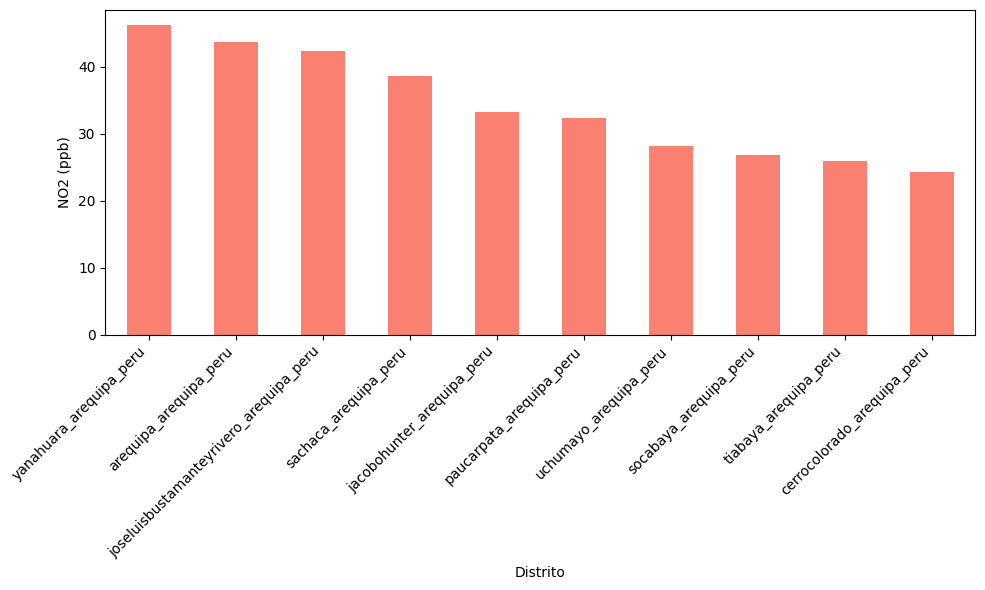

In [279]:
top_no2.plot(
    kind='bar',
    x='district_name',
    y='value',
    legend=False,
    figsize=(10, 6),
    color='salmon'
)

plt.xlabel('Distrito')
plt.ylabel('NO2 (ppb)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Create dfs per day period

In [280]:
df_no2_morning = df_no2[df_no2['day_period'] == 'morning']
df_no2_evening = df_no2[df_no2['day_period'] == 'evening']
df_no2_night = df_no2[df_no2['day_period'] == 'night']

## Define min max scale function

In [281]:
def min_max_scale(df: pd.DataFrame, key: str):
    df[f'scaled_{key}'] = df[key].apply(lambda x: (x - df[key].min()) / (df[key].max() - df[key].min()))
    return df



## Scaling three dataframes for obtaining traffic index (scaled_value)

In [282]:
min_max_scale(df_no2_morning, key="value")
min_max_scale(df_no2_evening, key="value")
min_max_scale(df_no2_night, key="value")

/tmp/ipython-input-884738505.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'scaled_{key}'] = df[key].apply(lambda x: (x - df[key].min()) / (df[key].max() - df[key].min()))
/tmp/ipython-input-884738505.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'scaled_{key}'] = df[key].apply(lambda x: (x - df[key].min()) / (df[key].max() - df[key].min()))
/tmp/ipython-input-884738505.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

,district_name,pollutant_code,day_period,value,latitude,longitude,units,scaled_value
6,altoselvaalegre_arequipa_peru,no2,night,21.430000,-16.331058,-71.485530,PARTS_PER_BILLION,0.434964
30,arequipa_arequipa_peru,no2,night,43.696667,-16.406798,-71.524124,PARTS_PER_BILLION,0.944335
54,cayma_arequipa_peru,no2,night,15.746000,-16.266398,-71.457130,PARTS_PER_BILLION,0.304937
78,cerrocolorado_arequipa_peru,no2,night,24.218000,-16.304421,-71.562532,PARTS_PER_BILLION,0.498742
102,characato_arequipa_peru,no2,night,12.850000,-16.457742,-71.368802,PARTS_PER_BILLION,0.238688
126,chiguata_arequipa_peru,no2,night,12.866000,-16.362086,-71.358645,PARTS_PER_BILLION,0.239054
150,jacobohunter_arequipa_peru,no2,night,33.147500,-16.458778,-71.562713,PARTS_PER_BILLION,0.703013
174,joseluisbustamanteyrivero_arequipa_peru,no2,night,42.325000,-16.431730,-71.523013,PARTS_PER_BILLION,0.912957
198,lajoya_arequipa_peru,no2,night,11.048000,-16.588392,-71.795725,PARTS_PER_BILLION,0.197465
222,marianomelgar_arequipa_peru,no2,night,20.540000,-16.361976,-71.462944,PARTS_PER_BILLION,0.414604


# Denuncias policiales

The data was downloaded from the below link

https://www.datosabiertos.gob.pe/dataset/denuncias-policiales-1

In [283]:
df_denuncias = pd.read_csv('denuncias.csv')

In [284]:
df_denuncias.sample(10)

,ANIO,MES,DPTO_HECHO_NEW,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,P_MODALIDADES,cantidad
314061,2025,5,ANCASH,CARLOS FERMIN FITZCARRALD,SAN LUIS,20701,Extorsión,1
252362,2024,1,PIURA,PIURA,LA ARENA,200109,Extorsión,1
19023,2018,8,AYACUCHO,LA MAR,TAMBO,50508,Violencia contra la mujer e integrantes,1
249858,2024,1,AREQUIPA,CAMANA,QUILCA,40207,Violencia contra la mujer e integrantes,1
23661,2018,9,PUNO,SAN ROMAN,CABANILLAS,211103,Otros,6
297837,2024,12,REGION LIMA,YAUYOS,LINCHA,151019,Otros,2
317466,2025,5,SAN MARTIN,RIOJA,AWAJUN,220802,Hurto,3
186985,2022,9,LIMA METROPOLITANA,LIMA,LURIGANCHO - CHOSICA,150118,Robo,34
212007,2023,3,SAN MARTIN,TOCACHE,TOCACHE,221001,Robo,4
273964,2024,7,ANCASH,SIHUAS,RAGASH,21908,Otros,1


In [285]:
df_denuncias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324993 entries, 0 to 324992
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   ANIO            324993 non-null  int64 
 1   MES             324993 non-null  int64 
 2   DPTO_HECHO_NEW  324993 non-null  object
 3   PROV_HECHO      324993 non-null  object
 4   DIST_HECHO      324993 non-null  object
 5   UBIGEO_HECHO    324993 non-null  int64 
 6   P_MODALIDADES   324993 non-null  object
 7   cantidad        324993 non-null  int64 
dtypes: int64(4), object(4)
memory usage: 19.8+ MB


## Focus analysis in 2025 and Arequipa Department

In [286]:
df_aqp_last_year = df_denuncias[(df_denuncias['ANIO'] == 2025) & (df_denuncias['DPTO_HECHO_NEW'] == 'AREQUIPA')]

In [287]:
df_aqp_last_year.head()

,ANIO,MES,DPTO_HECHO_NEW,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,P_MODALIDADES,cantidad
298676,2025,1,AREQUIPA,AREQUIPA,ALTO SELVA ALEGRE,40102,Estafa,12
298677,2025,1,AREQUIPA,AREQUIPA,ALTO SELVA ALEGRE,40102,Extorsión,2
298678,2025,1,AREQUIPA,AREQUIPA,ALTO SELVA ALEGRE,40102,Homicidio,1
298679,2025,1,AREQUIPA,AREQUIPA,ALTO SELVA ALEGRE,40102,Hurto,40
298680,2025,1,AREQUIPA,AREQUIPA,ALTO SELVA ALEGRE,40102,Otros,78


In [288]:
df_aqp_last_year['DIST_HECHO'].unique().tolist()

['ALTO SELVA ALEGRE',
 'AREQUIPA',
 'CAYMA',
 'CERRO COLORADO',
 'CHARACATO',
 'CHIGUATA',
 'JACOBO HUNTER',
 'JOSE LUIS BUSTAMANTE Y RIVERO',
 'LA JOYA',
 'MARIANO MELGAR',
 'MIRAFLORES',
 'MOLLEBAYA',
 'PAUCARPATA',
 'POCSI',
 'POLOBAYA',
 'QUEQUEÑA',
 'SABANDIA',
 'SACHACA',
 'SAN JUAN DE SIGUAS',
 'SANTA RITA DE SIGUAS',
 'SOCABAYA',
 'TIABAYA',
 'UCHUMAYO',
 'VITOR',
 'YANAHUARA',
 'YARABAMBA',
 'YURA',
 'CAMANA',
 'JOSE MARIA QUIMPER',
 'MARIANO NICOLAS VALCARCEL',
 'MARISCAL CACERES',
 'NICOLAS DE PIEROLA',
 'OCOÑA',
 'QUILCA',
 'SAMUEL PASTOR',
 'ACARI',
 'ATICO',
 'BELLA UNION',
 'CARAVELI',
 'CHALA',
 'CHAPARRA',
 'HUANUHUANU',
 'JAQUI',
 'LOMAS',
 'QUICACHA',
 'YAUCA',
 'ANDAGUA',
 'APLAO',
 'AYO',
 'CHACHAS',
 'CHILCAYMARCA',
 'CHOCO',
 'HUANCARQUI',
 'MACHAGUAY',
 'ORCOPAMPA',
 'PAMPACOLCA',
 'TIPAN',
 'URACA',
 'VIRACO',
 'CABANACONDE',
 'CALLALLI',
 'CAYLLOMA',
 'CHIVAY',
 'HUAMBO',
 'HUANCA',
 'ICHUPAMPA',
 'LARI',
 'MACA',
 'MADRIGAL',
 'MAJES',
 'SAN ANTONIO DE CHUCA'

## Show crime types

In [289]:
df_aqp_last_year['P_MODALIDADES'].unique()

array(['Estafa', 'Extorsión', 'Homicidio', 'Hurto', 'Otros', 'Robo',
       'Violencia contra la mujer e integrantes'], dtype=object)

## Filter by common crimes: "Homicidio, Hurto, Robo"

In [290]:
df_aqp_last_year_common = df_aqp_last_year[df_aqp_last_year['P_MODALIDADES'].isin(['Homicidio', 'Hurto', 'Robo'])]

## Normalize district name

In [291]:
df_aqp_last_year_common['district_name'] =  df_aqp_last_year_common['DIST_HECHO'].str.replace(' ', '').str.lower() + '_arequipa_peru'

/tmp/ipython-input-1640064841.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aqp_last_year_common['district_name'] =  df_aqp_last_year_common['DIST_HECHO'].str.replace(' ', '').str.lower() + '_arequipa_peru'


In [292]:
df_aqp_last_year_common

,ANIO,MES,DPTO_HECHO_NEW,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,P_MODALIDADES,cantidad,district_name
298678,2025,1,AREQUIPA,AREQUIPA,ALTO SELVA ALEGRE,40102,Homicidio,1,altoselvaalegre_arequipa_peru
298679,2025,1,AREQUIPA,AREQUIPA,ALTO SELVA ALEGRE,40102,Hurto,40,altoselvaalegre_arequipa_peru
298681,2025,1,AREQUIPA,AREQUIPA,ALTO SELVA ALEGRE,40102,Robo,7,altoselvaalegre_arequipa_peru
298685,2025,1,AREQUIPA,AREQUIPA,AREQUIPA,40101,Homicidio,1,arequipa_arequipa_peru
298686,2025,1,AREQUIPA,AREQUIPA,AREQUIPA,40101,Hurto,86,arequipa_arequipa_peru
...,...,...,...,...,...,...,...,...,...
322078,2025,7,AREQUIPA,ISLAY,MEJIA,40705,Hurto,1,mejia_arequipa_peru
322082,2025,7,AREQUIPA,ISLAY,MOLLENDO,40701,Hurto,3,mollendo_arequipa_peru
322084,2025,7,AREQUIPA,ISLAY,MOLLENDO,40701,Robo,1,mollendo_arequipa_peru
322086,2025,7,AREQUIPA,ISLAY,PUNTA DE BOMBON,40706,Hurto,1,puntadebombon_arequipa_peru


## Sum number of crimes per district

In [293]:
df_aqp = df_aqp_last_year_common.groupby(['district_name']).agg({
    'cantidad': 'sum',
}).reset_index()

In [294]:
top_crimes = df_aqp.sort_values(by="cantidad", ascending=False).head(10)
top_crimes

,district_name,cantidad
5,arequipa_arequipa_peru,1125
15,cerrocolorado_arequipa_peru,960
51,paucarpata_arequipa_peru,664
35,joseluisbustamanteyrivero_arequipa_peru,441
14,cayma_arequipa_peru,394
44,miraflores_arequipa_peru,328
40,marianomelgar_arequipa_peru,317
69,socabaya_arequipa_peru,313
3,altoselvaalegre_arequipa_peru,309
76,yanahuara_arequipa_peru,282


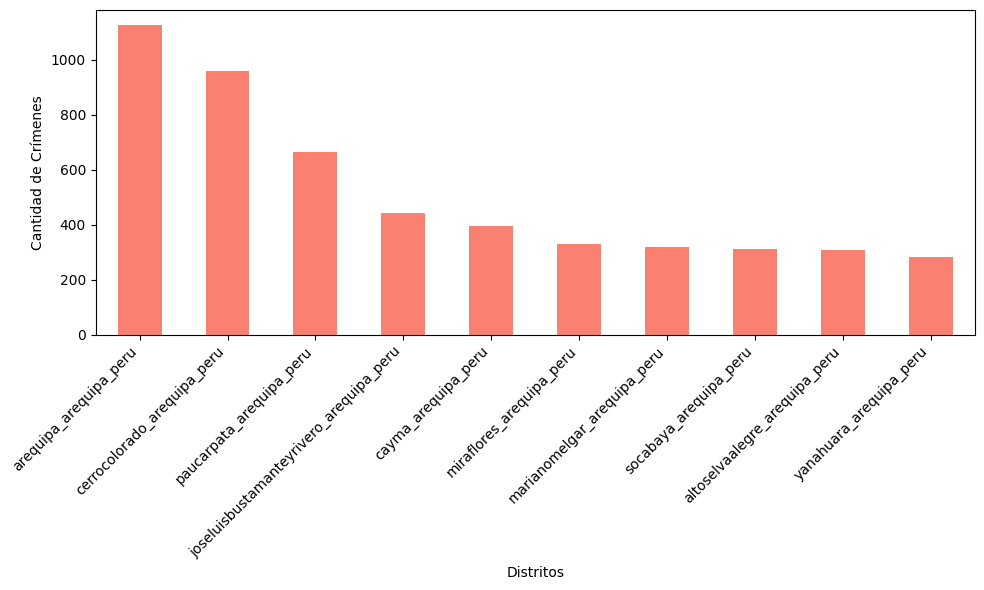

In [295]:
top_crimes.plot(
    kind='bar',
    x='district_name',
    y='cantidad',
    legend=False,
    figsize=(10, 6),
    color='salmon'
)

plt.xlabel('Distritos')
plt.ylabel('Cantidad de Crímenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Scaled to obtain criminality index (scaled cantidad)

In [296]:
min_max_scale(df_aqp, key='cantidad')

,district_name,cantidad,scaled_cantidad
0,acari_arequipa_peru,9,0.007117
1,achoma_arequipa_peru,3,0.001779
2,alca_arequipa_peru,4,0.002669
3,altoselvaalegre_arequipa_peru,309,0.274021
4,aplao_arequipa_peru,15,0.012456
...,...,...,...
77,yanaquihua_arequipa_peru,4,0.002669
78,yanque_arequipa_peru,5,0.003559
79,yarabamba_arequipa_peru,17,0.014235
80,yauca_arequipa_peru,13,0.010676


## Show district names for dataframes to validate the merging by district name

In [297]:
df_aqp['district_name'].unique().tolist()

['acari_arequipa_peru',
 'achoma_arequipa_peru',
 'alca_arequipa_peru',
 'altoselvaalegre_arequipa_peru',
 'aplao_arequipa_peru',
 'arequipa_arequipa_peru',
 'atico_arequipa_peru',
 'bellaunion_arequipa_peru',
 'cabanaconde_arequipa_peru',
 'callalli_arequipa_peru',
 'camana_arequipa_peru',
 'caraveli_arequipa_peru',
 'cayarani_arequipa_peru',
 'caylloma_arequipa_peru',
 'cayma_arequipa_peru',
 'cerrocolorado_arequipa_peru',
 'chala_arequipa_peru',
 'chaparra_arequipa_peru',
 'characato_arequipa_peru',
 'charcana_arequipa_peru',
 'chichas_arequipa_peru',
 'chiguata_arequipa_peru',
 'chivay_arequipa_peru',
 'chuquibamba_arequipa_peru',
 'cocachacra_arequipa_peru',
 'coporaque_arequipa_peru',
 'cotahuasi_arequipa_peru',
 'deanvaldivia_arequipa_peru',
 'huambo_arequipa_peru',
 'huanca_arequipa_peru',
 'huancarqui_arequipa_peru',
 'huanuhuanu_arequipa_peru',
 'islay_arequipa_peru',
 'jacobohunter_arequipa_peru',
 'jaqui_arequipa_peru',
 'joseluisbustamanteyrivero_arequipa_peru',
 'josemari

In [298]:
df_no2_evening['district_name'].unique().tolist()

['altoselvaalegre_arequipa_peru',
 'arequipa_arequipa_peru',
 'cayma_arequipa_peru',
 'cerrocolorado_arequipa_peru',
 'characato_arequipa_peru',
 'chiguata_arequipa_peru',
 'jacobohunter_arequipa_peru',
 'joseluisbustamanteyrivero_arequipa_peru',
 'lajoya_arequipa_peru',
 'marianomelgar_arequipa_peru',
 'miraflores_arequipa_peru',
 'mollebaya_arequipa_peru',
 'paucarpata_arequipa_peru',
 'pocsi_arequipa_peru',
 'polobaya_arequipa_peru',
 'quequeña_arequipa_peru',
 'sabandia_arequipa_peru',
 'sachaca_arequipa_peru',
 'sanjuandesiguas_arequipa_peru',
 'sanjuandetarucani_arequipa_peru',
 'santaisabeldesiguas_arequipa_peru',
 'santaritadesiguas_arequipa_peru',
 'socabaya_arequipa_peru',
 'tiabaya_arequipa_peru',
 'uchumayo_arequipa_peru',
 'vitor_arequipa_peru',
 'yanahuara_arequipa_peru',
 'yarabamba_arequipa_peru',
 'yura_arequipa_peru']

## Merge dataframes and adding criminality index if found

In [299]:
df_no2_morning_aqp = pd.merge(
    df_no2_morning,
    df_aqp,
    how="left",
    on='district_name'
)

df_no2_evening_aqp = pd.merge(
    df_no2_evening,
    df_aqp,
    how="left",
    on='district_name'
)

df_no2_night_aqp = pd.merge(
    df_no2_night,
    df_aqp,
    how="left",
    on='district_name'
)

## Show evening evening data after merging

In [300]:
df_no2_evening_aqp

,district_name,pollutant_code,day_period,value,latitude,longitude,units,scaled_value,cantidad,scaled_cantidad
0,altoselvaalegre_arequipa_peru,no2,evening,1.000,-16.331058,-71.485530,PARTS_PER_BILLION,0.055506,309,0.274021
1,arequipa_arequipa_peru,no2,evening,10.980,-16.406798,-71.524124,PARTS_PER_BILLION,0.790194,1125,1.000000
2,cayma_arequipa_peru,no2,evening,0.856,-16.266398,-71.457130,PARTS_PER_BILLION,0.044906,394,0.349644
3,cerrocolorado_arequipa_peru,no2,evening,1.120,-16.304421,-71.562532,PARTS_PER_BILLION,0.064340,960,0.853203
4,characato_arequipa_peru,no2,evening,0.686,-16.457742,-71.368802,PARTS_PER_BILLION,0.032391,54,0.047153
5,chiguata_arequipa_peru,no2,evening,1.632,-16.362086,-71.358645,PARTS_PER_BILLION,0.102032,22,0.018683
6,jacobohunter_arequipa_peru,no2,evening,4.495,-16.458778,-71.562713,PARTS_PER_BILLION,0.312794,139,0.122776
7,joseluisbustamanteyrivero_arequipa_peru,no2,evening,8.765,-16.431730,-71.523013,PARTS_PER_BILLION,0.627135,441,0.391459
8,lajoya_arequipa_peru,no2,evening,0.498,-16.588392,-71.795725,PARTS_PER_BILLION,0.018551,142,0.125445
9,marianomelgar_arequipa_peru,no2,evening,0.950,-16.361976,-71.462944,PARTS_PER_BILLION,0.051826,317,0.281139


## Calculating urban risk index based on traffic index(scaled_value) and criminality index(scaled_cantidad)

In [301]:
df_no2_morning_aqp["urban_risk_index"] = df_no2_morning_aqp["scaled_value"]*0.5 + df_no2_morning_aqp["scaled_cantidad"]*0.5
df_no2_evening_aqp["urban_risk_index"] = df_no2_evening_aqp["scaled_value"]*0.5 + df_no2_evening_aqp["scaled_cantidad"]*0.5
df_no2_night_aqp["urban_risk_index"] = df_no2_night_aqp["scaled_value"]*0.5 + df_no2_night_aqp["scaled_cantidad"]*0.5

In [302]:
df_no2_morning_aqp.sort_values(by="urban_risk_index", ascending=False)

,district_name,pollutant_code,day_period,value,latitude,longitude,units,scaled_value,cantidad,scaled_cantidad,urban_risk_index
1,arequipa_arequipa_peru,no2,morning,20.5900,-16.406798,-71.524124,PARTS_PER_BILLION,0.894908,1125,1.000000,0.947454
26,yanahuara_arequipa_peru,no2,morning,22.4600,-16.394789,-71.550419,PARTS_PER_BILLION,1.000000,282,0.250000,0.625000
3,cerrocolorado_arequipa_peru,no2,morning,11.5600,-16.304421,-71.562532,PARTS_PER_BILLION,0.387434,960,0.853203,0.620318
7,joseluisbustamanteyrivero_arequipa_peru,no2,morning,18.4100,-16.431730,-71.523013,PARTS_PER_BILLION,0.772395,441,0.391459,0.581927
12,paucarpata_arequipa_peru,no2,morning,14.4240,-16.420118,-71.463864,PARTS_PER_BILLION,0.548387,664,0.589858,0.569122
17,sachaca_arequipa_peru,no2,morning,15.9900,-16.421063,-71.576245,PARTS_PER_BILLION,0.636394,97,0.085409,0.360902
22,socabaya_arequipa_peru,no2,morning,12.0680,-16.473317,-71.548771,PARTS_PER_BILLION,0.415983,313,0.277580,0.346781
6,jacobohunter_arequipa_peru,no2,morning,14.0150,-16.458778,-71.562713,PARTS_PER_BILLION,0.525402,139,0.122776,0.324089
0,altoselvaalegre_arequipa_peru,no2,morning,10.3760,-16.331058,-71.485530,PARTS_PER_BILLION,0.320895,309,0.274021,0.297458
10,miraflores_arequipa_peru,no2,morning,9.9200,-16.356375,-71.471123,PARTS_PER_BILLION,0.295268,328,0.290925,0.293097


In [303]:
df_no2_evening_aqp.sort_values(by="urban_risk_index", ascending=False)

,district_name,pollutant_code,day_period,value,latitude,longitude,units,scaled_value,cantidad,scaled_cantidad,urban_risk_index
1,arequipa_arequipa_peru,no2,evening,10.980,-16.406798,-71.524124,PARTS_PER_BILLION,0.790194,1125,1.000000,0.895097
26,yanahuara_arequipa_peru,no2,evening,13.830,-16.394789,-71.550419,PARTS_PER_BILLION,1.000000,282,0.250000,0.625000
12,paucarpata_arequipa_peru,no2,evening,6.868,-16.420118,-71.463864,PARTS_PER_BILLION,0.487485,664,0.589858,0.538671
7,joseluisbustamanteyrivero_arequipa_peru,no2,evening,8.765,-16.431730,-71.523013,PARTS_PER_BILLION,0.627135,441,0.391459,0.509297
3,cerrocolorado_arequipa_peru,no2,evening,1.120,-16.304421,-71.562532,PARTS_PER_BILLION,0.064340,960,0.853203,0.458772
17,sachaca_arequipa_peru,no2,evening,6.446,-16.421063,-71.576245,PARTS_PER_BILLION,0.456419,97,0.085409,0.270914
22,socabaya_arequipa_peru,no2,evening,2.530,-16.473317,-71.548771,PARTS_PER_BILLION,0.168139,313,0.277580,0.222860
6,jacobohunter_arequipa_peru,no2,evening,4.495,-16.458778,-71.562713,PARTS_PER_BILLION,0.312794,139,0.122776,0.217785
2,cayma_arequipa_peru,no2,evening,0.856,-16.266398,-71.457130,PARTS_PER_BILLION,0.044906,394,0.349644,0.197275
10,miraflores_arequipa_peru,no2,evening,0.950,-16.356375,-71.471123,PARTS_PER_BILLION,0.051826,328,0.290925,0.171375


In [304]:
df_no2_night_aqp.sort_values(by="urban_risk_index", ascending=False)

,district_name,pollutant_code,day_period,value,latitude,longitude,units,scaled_value,cantidad,scaled_cantidad,urban_risk_index
1,arequipa_arequipa_peru,no2,night,43.696667,-16.406798,-71.524124,PARTS_PER_BILLION,0.944335,1125,1.000000,0.972168
3,cerrocolorado_arequipa_peru,no2,night,24.218000,-16.304421,-71.562532,PARTS_PER_BILLION,0.498742,960,0.853203,0.675972
7,joseluisbustamanteyrivero_arequipa_peru,no2,night,42.325000,-16.431730,-71.523013,PARTS_PER_BILLION,0.912957,441,0.391459,0.652208
12,paucarpata_arequipa_peru,no2,night,32.312000,-16.420118,-71.463864,PARTS_PER_BILLION,0.683900,664,0.589858,0.636879
26,yanahuara_arequipa_peru,no2,night,46.130000,-16.394789,-71.550419,PARTS_PER_BILLION,1.000000,282,0.250000,0.625000
17,sachaca_arequipa_peru,no2,night,38.588000,-16.421063,-71.576245,PARTS_PER_BILLION,0.827469,97,0.085409,0.456439
22,socabaya_arequipa_peru,no2,night,26.868000,-16.473317,-71.548771,PARTS_PER_BILLION,0.559363,313,0.277580,0.418472
6,jacobohunter_arequipa_peru,no2,night,33.147500,-16.458778,-71.562713,PARTS_PER_BILLION,0.703013,139,0.122776,0.412894
0,altoselvaalegre_arequipa_peru,no2,night,21.430000,-16.331058,-71.485530,PARTS_PER_BILLION,0.434964,309,0.274021,0.354492
10,miraflores_arequipa_peru,no2,night,20.350000,-16.356375,-71.471123,PARTS_PER_BILLION,0.410258,328,0.290925,0.350591


# Graph district heatmaps based on urban risk

In [305]:
with open("arequipa.txt", "r") as f:
    districts = f.readlines()

districts = [district.strip() for district in districts]

In [306]:
districts

['Arequipa, Arequipa, Peru',
 'Alto Selva Alegre, Arequipa, Peru',
 'Cayma, Arequipa, Peru',
 'Cerro Colorado, Arequipa, Peru',
 'Characato, Arequipa, Peru',
 'Chiguata, Arequipa, Peru',
 'Jacobo Hunter, Arequipa, Peru',
 'José Luis Bustamante y Rivero, Arequipa, Peru',
 'La Joya, Arequipa, Peru',
 'Mariano Melgar, Arequipa, Peru',
 'Miraflores, Arequipa, Peru',
 'Mollebaya, Arequipa, Peru',
 'Paucarpata, Arequipa, Peru',
 'Pocsi, Arequipa, Peru',
 'Polobaya, Arequipa, Peru',
 'Quequeña, Arequipa, Peru',
 'Sabandía, Arequipa, Peru',
 'Sachaca, Arequipa, Peru',
 'San Juan de Siguas, Arequipa, Peru',
 'San Juan de Tarucani, Arequipa, Peru',
 'Santa Isabel de Siguas, Arequipa, Peru',
 'Santa Rita de Siguas, Arequipa, Peru',
 'Socabaya, Arequipa, Peru',
 'Tiabaya, Arequipa, Peru',
 'Uchumayo, Arequipa, Peru',
 'Vítor, Arequipa, Peru',
 'Yanahuara, Arequipa, Peru',
 'Yarabamba, Arequipa, Peru',
 'Yura, Arequipa, Peru']

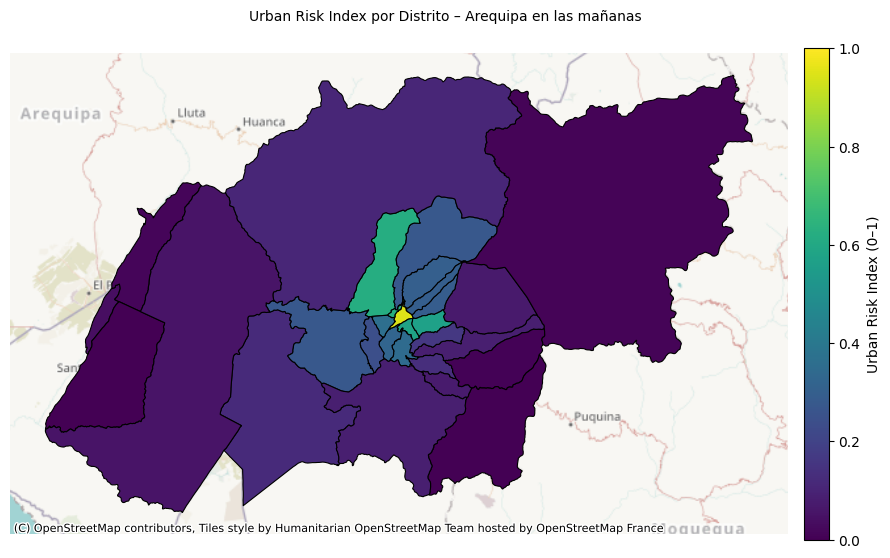

In [307]:
import re, unicodedata
import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as cx


gdfs = []
for q in districts:
    gd = ox.geocode_to_gdf(q)[["geometry"]].copy()
    gd["distrito"] = q.split(",")[0]
    gdfs.append(gd)

gdf_distritos = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs="EPSG:4326")



def norm_key(s: str) -> str:
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = s.lower()
    s = re.sub(r"_arequipa_peru$", "", s)
    s = re.sub(r"[^a-z]+", "", s)
    return s

gdf_distritos["key"] = gdf_distritos["distrito"].apply(norm_key)

df_scores = (
    df_no2_morning_aqp[["district_name", "urban_risk_index"]]
    .copy()
)
df_scores["key"] = df_scores["district_name"].apply(norm_key)


gdf_distritos = gdf_distritos.merge(
    df_scores[["key", "urban_risk_index"]],
    on="key",
    how="left"
)

# Control de valores (0–1) y faltantes
gdf_distritos["urban_risk_index"] = (
    gdf_distritos["urban_risk_index"]
    .astype(float)
)


gdf_distritos_3857 = gdf_distritos.to_crs(3857)

fig, ax = plt.subplots(figsize=(9, 9))

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=0, vmax=1)

gdf_distritos_3857.plot(
    ax=ax,
    column="urban_risk_index",
    cmap=cmap,
    edgecolor="black",
    linewidth=0.8,
    vmin=0, vmax=1,
    missing_kwds={"color": "lightgrey", "hatch": "///", "label": "Sin dato"}
)

# Basemap
cx.add_basemap(ax, crs=gdf_distritos_3857.crs, alpha=0.85)

# Barra de color
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Urban Risk Index (0–1)")

ax.set_axis_off()
plt.suptitle("Urban Risk Index por Distrito – Arequipa en las mañanas", fontsize=10, y=0.8)

plt.tight_layout()
plt.show()



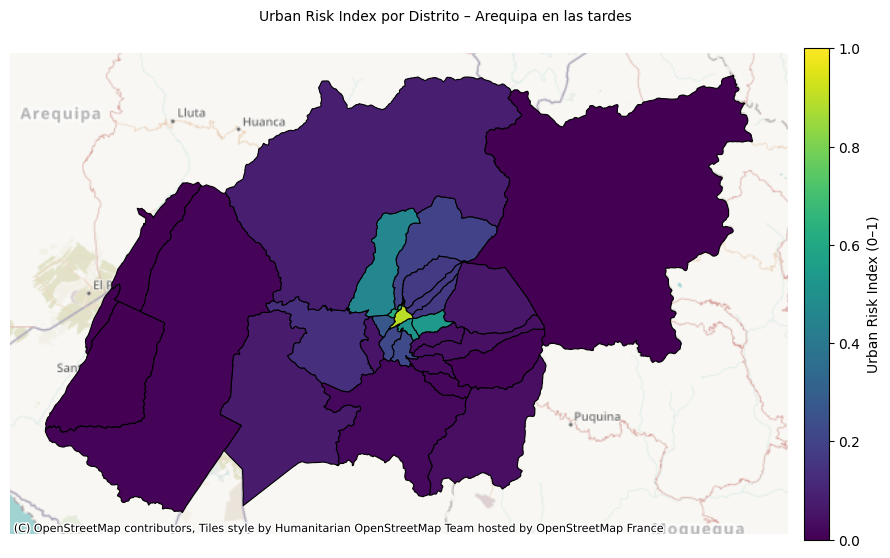

In [308]:
gdfs = []
for q in districts:
    gd = ox.geocode_to_gdf(q)[["geometry"]].copy()
    gd["distrito"] = q.split(",")[0]
    gdfs.append(gd)

gdf_distritos = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs="EPSG:4326")



def norm_key(s: str) -> str:
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = s.lower()
    s = re.sub(r"_arequipa_peru$", "", s)
    s = re.sub(r"[^a-z]+", "", s)
    return s

gdf_distritos["key"] = gdf_distritos["distrito"].apply(norm_key)

df_scores = (
    df_no2_evening_aqp[["district_name", "urban_risk_index"]]
    .copy()
)
df_scores["key"] = df_scores["district_name"].apply(norm_key)


gdf_distritos = gdf_distritos.merge(
    df_scores[["key", "urban_risk_index"]],
    on="key",
    how="left"
)

# Control de valores (0–1) y faltantes
gdf_distritos["urban_risk_index"] = (
    gdf_distritos["urban_risk_index"]
    .astype(float)
)


gdf_distritos_3857 = gdf_distritos.to_crs(3857)

fig, ax = plt.subplots(figsize=(9, 9))

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=0, vmax=1)

gdf_distritos_3857.plot(
    ax=ax,
    column="urban_risk_index",
    cmap=cmap,
    edgecolor="black",
    linewidth=0.8,
    vmin=0, vmax=1,
    missing_kwds={"color": "lightgrey", "hatch": "///", "label": "Sin dato"}
)

# Basemap
cx.add_basemap(ax, crs=gdf_distritos_3857.crs, alpha=0.85)

# Barra de color
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Urban Risk Index (0–1)")

ax.set_axis_off()
plt.suptitle("Urban Risk Index por Distrito – Arequipa en las tardes", fontsize=10, y=0.8)

plt.tight_layout()
plt.show()


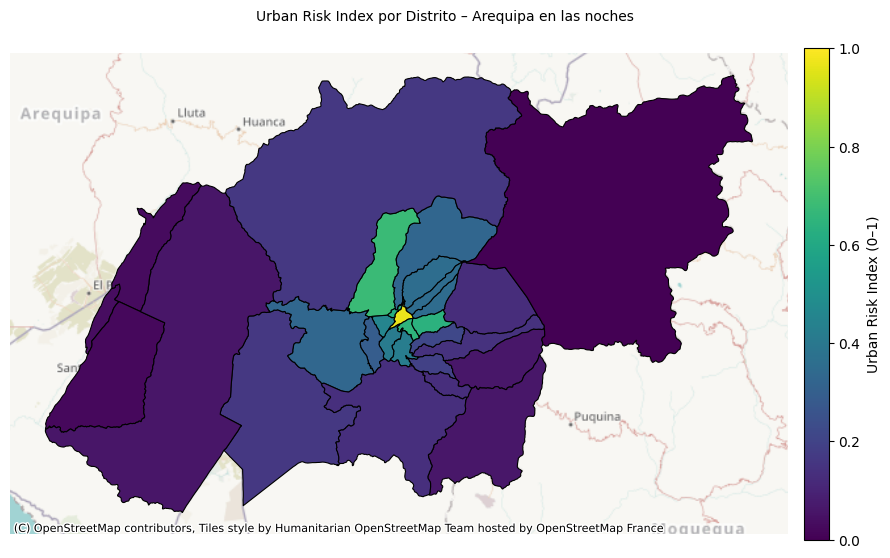

In [309]:
gdfs = []
for q in districts:
    gd = ox.geocode_to_gdf(q)[["geometry"]].copy()
    gd["distrito"] = q.split(",")[0]
    gdfs.append(gd)

gdf_distritos = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs="EPSG:4326")



def norm_key(s: str) -> str:
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = s.lower()
    s = re.sub(r"_arequipa_peru$", "", s)
    s = re.sub(r"[^a-z]+", "", s)
    return s

gdf_distritos["key"] = gdf_distritos["distrito"].apply(norm_key)

df_scores = (
    df_no2_night_aqp[["district_name", "urban_risk_index"]]
    .copy()
)
df_scores["key"] = df_scores["district_name"].apply(norm_key)


gdf_distritos = gdf_distritos.merge(
    df_scores[["key", "urban_risk_index"]],
    on="key",
    how="left"
)

# Control de valores (0–1) y faltantes
gdf_distritos["urban_risk_index"] = (
    gdf_distritos["urban_risk_index"]
    .astype(float)
)


gdf_distritos_3857 = gdf_distritos.to_crs(3857)

fig, ax = plt.subplots(figsize=(9, 9))

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=0, vmax=1)

gdf_distritos_3857.plot(
    ax=ax,
    column="urban_risk_index",
    cmap=cmap,
    edgecolor="black",
    linewidth=0.8,
    vmin=0, vmax=1,
    missing_kwds={"color": "lightgrey", "hatch": "///", "label": "Sin dato"}
)

# Basemap
cx.add_basemap(ax, crs=gdf_distritos_3857.crs, alpha=0.85)

# Barra de color
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Urban Risk Index (0–1)")

ax.set_axis_off()
plt.suptitle("Urban Risk Index por Distrito – Arequipa en las noches", fontsize=10, y=0.8)

plt.tight_layout()
plt.show()
